<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Basics of Markov Chain Monte Carlo <a class="tocSkip">

In this notebook we focus on a particular technique commonly used to explore probability distributions, most importantly, posteriors and likelihoods that are related to Bayesian inference and model comparison.

- We will use the Metropolis-Hastings algorithm to understand the basic principles behind MCMC.
- We will employ the popular library `emcee` and learn basic concepts such as chains, walkers, burn-in, and the stretch move.
- A more complex problem will be address at the end of the lecture, where we will learn reporting results with confidence intervals and corner plots.

# Setup

In [1]:
%pip install emcee --quiet
%pip install corner==2.2.2 --quiet

import numpy as np
import scipy.stats as st
import emcee
import corner
import requests
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.5 MB/s eta 0:00:00


Working in:
/content/astrostat-school-8/MCMC

Content:
	 ['MCMC.ipynb', 'MCMC_combined.ipynb', 'images']
Imported matplotlib.
Imported seaborn.
Plotting style set.


# 1. Introduction

## 1.1 Challenges in Bayesian inference

In the previous lectures we saw examples of parameter estimation for models of one parameter. We also estimated uncertainties, but this required a lot of steps. In this lecture we will see a general method that can be applied to both simple and complex models, able to naturally provide uncertainties.

*  ### Challenge 1: multiple parameters $\equiv$ multiple dimensions

If our model has many parameters, $\theta_1, \theta_2, \cdots, \theta_k$, then its posterior probability distribution is a $k$-dimensional function.

$$ \Large P(\theta_1, \theta_2, \cdots, \theta_k | \mathrm{Data}) $$

Finding the maximum of a $k$-D function is...way harder than in the 1-D or 2-D cases. Chances are that there are also multiple modes (local maxima and minima), which may not be found by all optimization algorithms.

We could try to compute the posterior in a $k$-dimensional **grid** and select the point with the highest value. However, a complex function might have narrow peaks requiring a high resolution grid in order to spot them. The higher the resolution and the number of dimensions the higher number of evaluations of the posterior, making the computation extremely time consuming.

*  ### Challenge 2: uncertainties

Maximizing the posterior provides a best-guess of the parameter values but not their uncertainties. There are approximate solutions to get an estimate of these uncertainties, but they usually make an assumption about the shape of the distribution (e.g. Gaussian around the peak).

*  ### Challenge 3: brute-force is non-optimal...

Another complication with grids is that we may spend a lot of time in uninteresting regions of the parameter space (*but see lecture on GPUs*), where the probability is low and nothing interesting is happening. Instead, we would like to spend more time around the peaks, the regions of high posterior probability.


<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/MCMC/images/testfunc.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=600><center><br>
        Figure 1. An example of an "artificial landscape" function, used to evaluate optimization algorithms, having various local minima and maxima. This is particular function is called "Mishra's bird function" (<a href="https://mpra.ub.uni-muenchen.de/2718/" target="_blank">Sudhanshu 2006</a>).<br></center></td></tr></table>


## 1.2 A solution through sampling

The posterior distribution is given by Bayes' theorem:

$$ \Large
p(\theta \mid \mathbf{y}) = \frac{p(\mathbf{y} \mid \mathbf{\theta}) \, p(\mathbf{\theta})}{p(\mathbf{y})}
$$

where:

- $\mathbf{\theta}$ represents the parameters we want to estimate,
- $\mathbf{y}$ represents the observed data,
- $p(\mathbf{\theta})$ is the prior probability, reflecting our beliefs about $\mathbf{\theta}$ before seeing the data,
- $p(\mathbf{y} \mid \mathbf{\theta})$ is the likelihood, the probability of observing the data given parameters $\mathbf{\theta}$,
- $p(\mathbf{y})$ is the evidence (or marginal likelihood), a normalizing *constant* ensuring the integral of the posterior (over $\mathbf{\theta}$) is unity.

The evidence is just the integral over the parameters $\mathbf{\theta}$, given by:

$$ \Large
p(\mathbf{y}) = \int p(\mathbf{y} \mid \mathbf{\theta}) \, p(\mathbf{\theta}) \, d\mathbf{\theta}
$$

where it is the total probability of observing the data, integrating over all possible parameter values.


**However**, this integral is usually high-dimensional, non-analytical, or computationally expensive — especially for complex models.

Instead of computing $p(\mathbf{\theta} \mid \mathbf{y})$ exactly, with **sampling** we can use the ratios of posterior values, so the normalizing constant cancels out.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: what's the difference between "optimization" and "sampling"?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

Optimization finds the "best-fit" solution - either a maximum or a minimum of some function. Sampling, and specifically MCMC sampling, aims to locate the bulk of the probability mass, or equivalenty, the region of the parameter space where the probability density is the highest. This includes the best-fit solution but also, crucially, uncertainties and correlations of the parameters.
    
</details>
</div>


# 2. The Markov Chain Monte Carlo technique

The Marcov Chain Monte Carlo (MCMC) is a widely used technique to sample from probability distributions, and therefore posteriors.

It is based on the idea of creating a chain of points in the parameter space, using the combination of (i) a random walk and (ii) a selection of points based on their relative probability.

An algorithm is used to ensure that the chain will reach **equilibrium**: after a number of steps (or length of the Markov chain) the chain will contain points that follow the same distribution, the **target distribution**.

> It is often characterized as one of the most influencial algorithms of the 20th century...

## 2.1 Metropolis-Hastings algorithm:

We will discuss the Metropolis-Hastings algorithm, but note that there are *many* other algorithms available out there. Here are the steps:

1. We start with one set of parameters $\theta_1$.
    In general, $\theta_1$ can be a vector of 1, 5, or even a million distinct parameters.
    This first value is the starting point of our Markov chain.
    <br>


2. Using *some method* we obtain a new trial set of parameters $\theta_2$. *A proposition for a new position.*
    
    - It is important that this set is based on the previous set, but chosen with some degree of randomness.
    
    - Depending only on the previous set, is an essential property of a *Markov chain*.
    
    - The randomness is where the *Monte Carlo* in MCMC comes from.
    
    - The simplest method to obtain new parameter values is to add some random (e.g. Gaussian) noise to our current value: $\theta_2 = \theta_1 + \epsilon$.  
      This is also called **step size**. One typically wants to tune the step size, $\epsilon$, to optimize the process for a given problem.
    <br>


3. We calculate and compare the posterior probabilities for both $\theta_1$ and $\theta_2$.

    - If the new parameter is more probable than the current one, $P(\theta_2) > P(\theta_1)$, we always move the chain to $\theta_2$.
    
    - If not, we **might** move to $\theta_2$ with probability equal to the ratio $P(\theta_2) \, / \, P(\theta_1)$. In practice, we draw a random number from a uniform distribution between 0 and 1. If that random number is less than the ratio, we move the chain to $\theta_2$. Else, we stay at $\theta_1$ for another iteration.
    <br>


4. Now that we have our new value for $\theta$, we return to step 2 and repeat for as many iterations as we want. Often this is in the thousands or more.


<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/MCMC/images/mh.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=600><center><br>
Figure 2. Illustration of the Metropolis-Hastings sampling algorithm. Note that the time step is on the x-axis and the true (Gaussian) posterior is shown on the right as the lack line. Dashed lines indicate rejected trial parameter sets. Image from: <a href=" https://commons.wikimedia.org/w/index.php?curid=130401255">Lee, Jaewook & Sung, Woosuk & Choi, Joo-Ho (2015)</a>
<br></center></td></tr></table>


## 2.2 Let's implement the M-H algorithm...

In [2]:
def metro_hastings(ln_posterior, theta_0, N_steps, step_size=0.2, args=[], verbose=True):
    """Metropolis-Hastings algorith for sampling a posterior distribution of one parameter.

    Parameters
    ----------
    ln_posterior : function that returns the logarithm of the posterior
    theta_0      : initial guess for the model parameter
    N_steps      : the length of the Markov Chain that will be returned
    step_size    : the step size is random, coming from a normal (Gaussian) distribution with this standard deviation (and mean equal to zero).
    args         : additional arguments to be passed to the posterior function

    Returns
    -------
    A numpy array containing the Markov Chain. The index of this array corresponds to the time step.

    """
    chain = np.zeros(N_steps)                       # create the chain
    chain[0] = theta_0                              # store the initial point...
    if verbose:
        print(f"{chain[0]:.3g}", end=",")   # ...and print it!

    # hold the current value of the posterior to avoid recomputing it if position is not changed
    curr_P = ln_posterior(theta_0, *args)

    # populate the rest of the points in the chain
    for i in range(N_steps - 1):
        new_theta = chain[i] + np.random.normal(scale=step_size)
        new_P = ln_posterior(new_theta, *args)

        # should we move to the new position?
        if (new_P > curr_P) or (np.random.rand() < np.exp(new_P - curr_P)):
            # if yes... store the new value, print it and update the 'current posterior'
            chain[i + 1] = new_theta
            if verbose:
                print(f"{new_theta:.3g}", end=", ")
            curr_P = new_P
        else:
            # if not... store again the current position and print a '.'
            chain[i + 1] = chain[i]
            if verbose:
                print(".", end=" ")

    return chain

## 2.3 A toy model

When massive stars ($> 8 M_\odot$) collapse, most likely producing a supernova explosion, they form neutron stars (NS) or black holes. Newly formed NSs receive "kicks" with velocities typically in the range 100-500 km/s. One distribution that matches that of the kick velocities is the **Maxwellian**, as it has been shown by studies of pulsars ([Hobbs et al. 2006](https://ui.adsabs.harvard.edu/abs/2005MNRAS.360..974H/abstract)).

The Maxwellian distribution (i.e., Maxwell-Boltzmann from Statistical Mechanics) has only one parameter, $a$, which sets the magnitude of the velocities (note that $a$ is neither the mean nor the mode):

$$ \Large
            f(x \mid a) = \sqrt{\dfrac{2}{\pi}} \frac{x^2}{a^3} \exp\left({-\frac{x^2}{2a^2}}\right)
$$

Here, we will use this distribution to generate mock data and then perform a model fit. For the model, we will use the same one-parameter distribution, which means that we are already using the correct model and the goal is to fit its parameters. For example, if we didn't know that the distribution was a Maxwellian, we might have chosen to start with a Gaussian kick velocity distribution (two free parameters). Later in this notebook, we will use a mix of two Maxwellians as the model, which results in three free parameters.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: do the units of the Maxwellian make sense?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

Yes! The quantities $x$ and $a$ are in units of velocity, and $f$ is in units of inverse velocity, as it should because this function corresponds to a probability density.
    
</details>
</div>

## 2.4 The data

Let's make an artificial dataset:

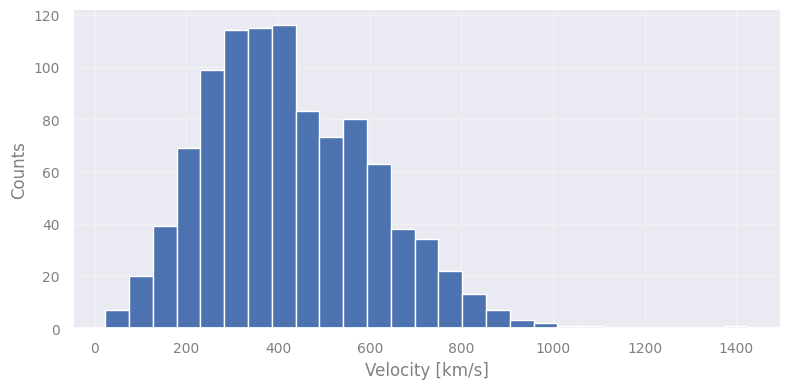

In [3]:
def make_velocity_sample(a1, a2, f, N):
    """Make a NS kick velocity distribution.
    We can use this function with either one or two Maxwellian components (and their relative contribution).
    The latter is used later in the notebook.

    a1 = the scale parameter of the Electron Capture SuperNova kick velocity distribution
    a2 = the scale parameter of the Core Collapse SuperNova kick velocity distribution
     f = the fraction of NSs formed by ECSN
     N = the sample size
    """
    N_ECSN = st.binom(N, f).rvs()
    N_CCSN = N - N_ECSN

    # the two kick velocity distributions
    distribution_ECSN = st.maxwell(scale=a1)
    distribution_CCSN = st.maxwell(scale=a2)
    # make samples from both distributions and join them
    sample = np.concatenate([distribution_ECSN.rvs(size=N_ECSN), distribution_CCSN.rvs(size=N_CCSN)])
    # shuffle the array to make sure we cannot distinguish the two samples anymore
    np.random.shuffle(sample)
    return sample


a = 265.0 # km/s
N = 1000 # km/s

sample_1 = make_velocity_sample(a, a, 0.0, N=N)

plt.figure()
plt.hist(sample_1, bins="fd")
plt.xlabel(r'Velocity [km/s]')
plt.ylabel(r'Counts')
plt.show()

## 2.5 Defining the posterior of our problem

For the **prior**, we use a uniform distribution that allows only for positive values (improper prior). This is basically just a constant that multiplies every likelihood, so its actual value doesn't affect probability comparisons and ratios (see step 3 in 2.1).

It is common to use the logarithm of the **likelihood** because of its very low values over large parts of the parameter space. This is conveniently provided by the `scipy.maxwell.logpdf` function. Note that `scipy` provides a `log` version of each distribution function optimized for better accuracy when dealing with small numbers.

In [21]:
def ln_prior(a):
    return -np.inf if a <= 0 else 0.0

def datum_ln_likelihood(v, a):
    return st.maxwell.logpdf(v, scale=a)

def ln_likelihood(velocities, a):
    return np.sum(datum_ln_likelihood(velocities, a))

def ln_posterior(a, velocities):
    result = ln_prior(a) + ln_likelihood(velocities, a)
    return -np.inf if np.isnan(result) else result

## 2.6 Running the M-H algorithm

In [22]:
"""Metropolis-Hastings algorith for sampling a posterior distribution of one parameter.

    Parameters
    ----------
    ln_posterior : function that returns the logarithm of the posterior
    theta_0      : initial guess for the model parameter
    N_steps      : the length of the Markov Chain that will be returned
    step_size    : the standard deviation of the normally distributed step size
    args         : additional arguments to be passed to the posterior function

    Returns
    -------
    A numpy array containing the Markov Chain.

    """

alpha_0 = 400.0   # our initial guess, in [km/s]
step_size = 10    # a step size that is "appropriate", same units as the parameters explored.

chain = metro_hastings(ln_posterior, alpha_0, args=[sample_1],
                       step_size=step_size, N_steps=500)

400,. 375, 359, . . 349, 349, 345, 340, 339, . . . 334, . 330, 329, . 320, 308, 308, . 298, 269, . 263, . 262, . 268, 267, 257, . 256, 273, . 270, . 269, . . 267, 269, . 268, 267, . 263, . . . . . 266, 270, . 270, . 264, 261, . . 269, . . 270, . 268, . . . . 267, . 268, 266, . 267, 267, . . . . 267, . . . 267, 265, . . . . . . 266, 261, . . . . 260, 267, 270, 268, 269, . 275, 263, . 262, . 266, 275, . . . . 277, 276, 263, 265, . 267, 269, . . . . . 271, 269, . . . . . . . 269, 263, 267, . 265, . . . . . 270, 272, . 269, . . . . . . . . . . . . . . 269, 269, 267, . 266, 267, . 268, 268, 274, . . . 268, . . . . 269, 271, . . 266, 270, . . 267, 268, 269, . . . 266, 265, . 265, 272, 273, . . . 272, 263, . 265, . . . . . . 270, 266, . . . 266, 267, . 266, 269, . 262, . 271, . . 261, . . . . 266, . . . . . . 267, 270, . 274, 269, . . . . 265, . . 265, . . 264, 270, . 262, . 266, . . . 265, . . . . . 268, 268, 267, . . . 264, . . 269, 272, . . . . 276, 269, . 268, . . . 267, . . 272, 260, 271

## 2.7 The produced Markov Chain and the *burn-in* phase

The first steps in the chain are usually less informative or useful. This is called the "burn-in" phase and it is safe to disregard the first steps and thrown them away. In principle, there is no absolute way to determine if a chain has moved out of the burn-in phase and into the optimal region of parameter space. In practice, unless your problem is pathological, it is usually pretty obvious. Be aware that this can be an issue and take care!

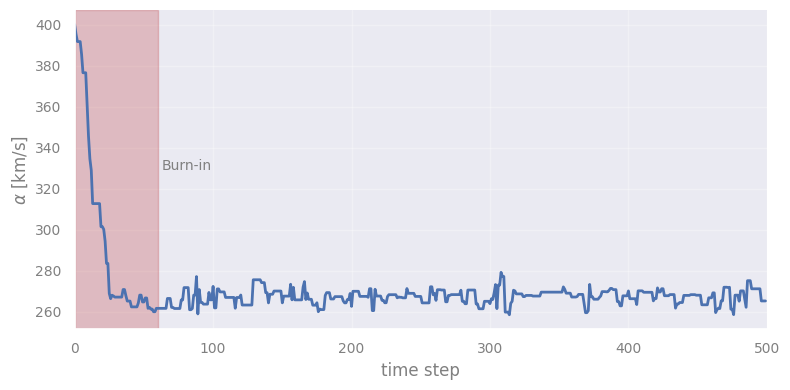

In [6]:
n_burnin = 60   # number of time steps from the start that will be rejected. Change this value if needed

plt.figure()
plt.axvspan(0, n_burnin, color="r", alpha=0.3)
plt.plot(chain)
_, _, y_min, y_max = plt.axis()
plt.text(n_burnin + 3, (y_min + y_max) / 2.0, "Burn-in")
chain_converged = chain[n_burnin:]
plt.xlim(0,len(chain))
plt.xlabel(r'time step')
plt.ylabel(r'$\alpha$ [km/s]')
plt.show()

## 2.8 The acceptance fraction

The acceptance fraction - how many of the trial parameter sets are accepted over the total - depends on the target distribution. It has been shown that for one-dimensional normal distributions, the optimal acceptance fraction is 50%, while for high dimensional normal distributions it is 23.4%, see <a href="https://doi.org/10.1214/aoap/1034625254">Gelman A., Gilks W.R., and Roberts G.O. (1997)</a>.

A Very small or large acceptance fraction indicates that the step size is not optimal and the algorithm struggles to reach the target distribution. By tuning the step size, $\epsilon$, the procedure becomes more efficient. Increasing/decreasing $\epsilon$ might affect the duration of the burn-in phase.

In [23]:
# The diff routine calculates the difference between neighbouring array elements.
# If this difference is zero, then the chain did not move (trial parameters rejected).
accepted = np.diff(chain_converged) != 0

# The above line results in a boolean array containing True and False - its mean is the acceptance fraction.
print(f"Acceptance fraction: {np.mean(accepted):.3f}")

Acceptance fraction: 0.390


## 2.9 Reporting results as "$m \pm s$" or with confidence intervals

Now that we have an estimate of the posterior distribution of $\alpha$, we can plot the histogram of the values in the chain calculated for some bin size. Note that the ordering of values, or time steps, can be ignored from now on. We also calculate the mean, standard deviation, and 68% confidence intervals.

  mean +/- std |  267.383 +/- 3.522
median +upper -lower |  267.665 +2.927 -3.944


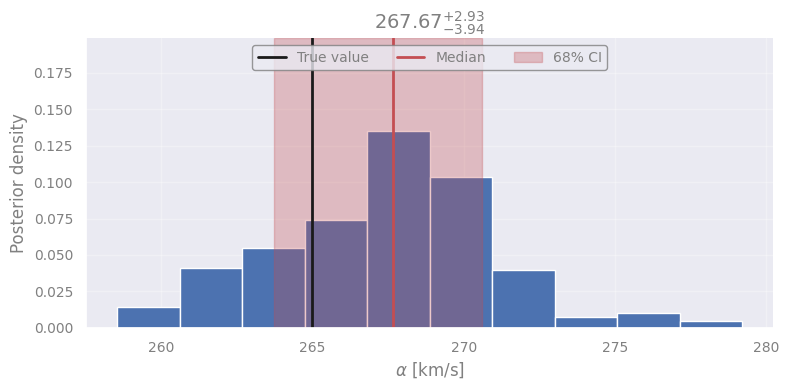

In [8]:
mean, std = np.mean(chain_converged), np.std(chain_converged)
lo68, median, hi68 = np.percentile(chain_converged, [16, 50, 84])

print("  mean +/- std |  {:.3f} +/- {:.3f}".format(mean, std))
print("median +upper -lower |  {:.3f} +{:.3f} -{:.3f}".format(
    median, hi68 - median, median - lo68))


plt.figure()
plt.hist(chain_converged, bins=10, density=True)
_, _, _, y_max = plt.axis()
plt.ylim(ymax=y_max*1.4)

plt.axvline(a, color="k", label="True value")
plt.axvline(median, color="r", linewidth=2, label="Median")
plt.axvspan(lo68, hi68, color="r", alpha=0.3, label="68% CI")
plt.title(r"${:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(median, hi68 - median, median - lo68))
plt.xlabel(r"$\alpha$ [km/s]")
plt.ylabel("Posterior density")
plt.legend(loc="upper center", ncol=3)
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 1: effect of initial position</b></font>

    
Re-run MCMC for three different starting points (Step 2.6).

<u>Does the initial position affect the result?</u>

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

It doesn't! The chains converge to the same solution but it may take a while if we start away from it!

</details>
</div>

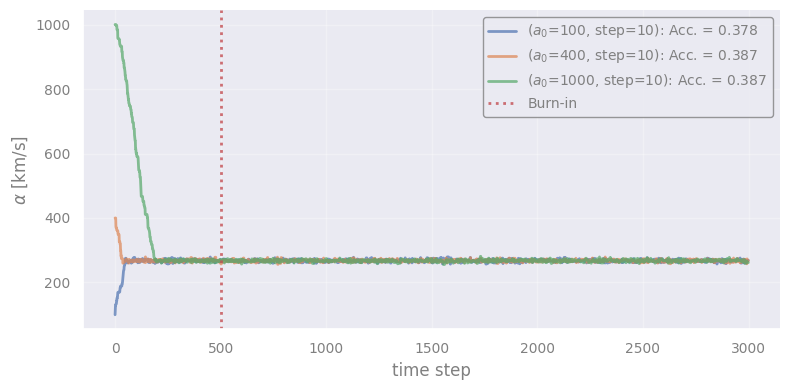

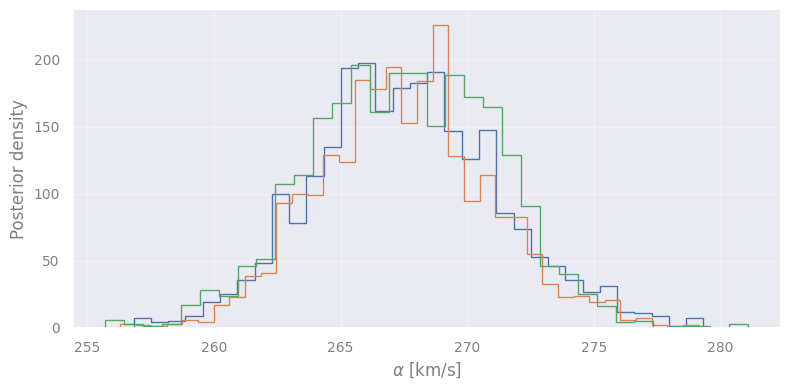

In [24]:
step_size = 10.0                   # our step size

alpha_0s = [100, 400, 1000]         # pick the initial guesses
step_sizes = [step_size] * 3       # the step sizes

N_steps = 3000
n_burnin = 500   # pick a value that is "safe" for all chains

# make all chains
chains = [metro_hastings(ln_posterior, alpha_0, args=[sample_1], step_size=step_size, N_steps=N_steps, verbose=False)
          for alpha_0, step_size in zip(alpha_0s, step_sizes)]
converged_chains = [chain[n_burnin:] for chain in chains]

# plot the chains and samples
plt.figure()
for alpha_0, step_size, chain, converged_chain in zip(alpha_0s, step_sizes, chains, converged_chains):
    acceptance_fraction = np.mean(np.diff(converged_chain) != 0)
    plt.plot(chain, alpha=0.7, label=f"($a_0$={alpha_0:.6g}, step={step_size:.6g}): Acc. = {acceptance_fraction:.3f}")
plt.axvline(n_burnin, color="r", ls=":", alpha=0.8, label="Burn-in")
plt.legend(loc="upper right")
plt.xlabel(r'time step')
plt.ylabel(r'$\alpha$ [km/s]')
plt.show()

plt.figure()
for alpha_0, step_size, converged_chain in zip(alpha_0s, step_sizes, converged_chains):
    plt.hist(converged_chain, bins="fd", histtype="step")
plt.xlabel(r"$\alpha$ [km/s]")
plt.ylabel("Posterior density")
plt.show()

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

<pre>
alpha_0s = [100.0, 400.0, 1000.0]  # pick the initial guesses
</pre>
  
</details>
</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 2: effect of step size</b></font>
    
Now try with the same initial guess (away for the solution, e.g., 400), but with different step sizes.

<u>How does the step size affect the convergence and result?</u>

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

The larger the step, the quicker we explore the parameter space and find the solution. However, this makes it harder to go to newly proposed positions and we are not efficiently sampling the posterior (small acceptance fraction).
With very small step sizes the convergence is so slow that the burn-in phase lasts for long, but we can't "lose" the solution. However, the acceptance fraction is too large: we are not efficiently exploring the space around the solution - it seems like a random walk around it.       Thus, we may need very long chains to converge to the correct posterior distribution.
Intermediate step sizes are optimal: quick convergence, good sampling of the posterior, acceptance fraction in the desired range.

</details>
</div>

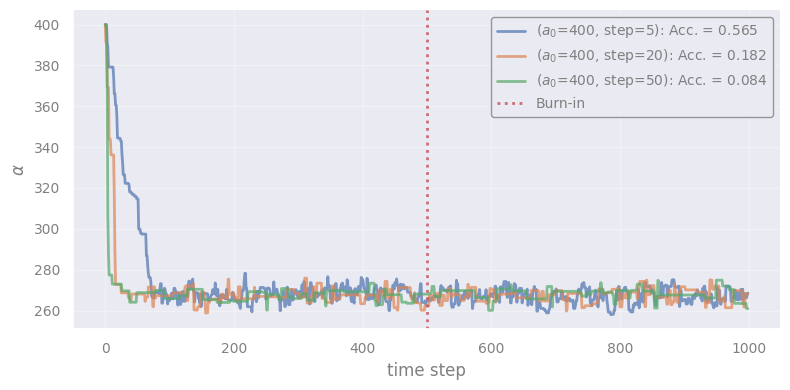

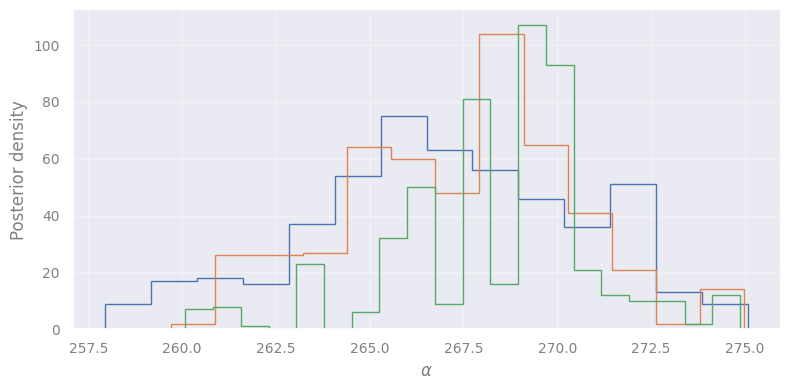

In [10]:
initial_position = 400.0           # pick an initial position away from the solution
alpha_0s = [initial_position] * 3
step_sizes = [5, 20, 50]    # pick the step sizes

N_steps = 1000
n_burnin = 500   # pick a value that is "safe" for all chains

# make all chains
chains = [metro_hastings(ln_posterior, alpha_0, args=[sample_1], step_size=step_size, N_steps=N_steps, verbose=False)
          for alpha_0, step_size in zip(alpha_0s, step_sizes)]
converged_chains = [chain[n_burnin:] for chain in chains]

# plot the chains and samples
plt.figure()
for alpha_0, step_size, chain, converged_chain in zip(alpha_0s, step_sizes, chains, converged_chains):
    acceptance_fraction = np.mean(converged_chain[:-1] != converged_chain[1:])
    plt.plot(chain, alpha=0.7, label=f"($a_0$={alpha_0:.6g}, step={step_size:.6g}): Acc. = {acceptance_fraction:.3f}")
plt.axvline(n_burnin, color="r", ls=":", alpha=0.8, label="Burn-in")
plt.legend(loc="upper right")
plt.xlabel(r'time step')
plt.ylabel(r'$\alpha$')
plt.show()

plt.figure()
for alpha_0, step_size, converged_chain in zip(alpha_0s, step_sizes, converged_chains):
    plt.hist(converged_chain, bins="fd", histtype="step")
plt.xlabel(r"$\alpha$")
plt.ylabel("Posterior density")
plt.show()

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

<pre>
step_sizes = [1.0, 10.0, 100.0]    # pick the step sizes
</pre>
  
</details>
</div>

# 3. The MCMC module... `emcee`:


There are various MCMC algorithms (or samplers) out there. One very good algorithm that does not require much tuning is Goodman & Weare’s Affine Invariant Markov chain Monte Carlo Ensemble Sampler (<a href="https://msp.org/camcos/2010/5-1/p04.xhtml">Goodman & Weare 2010</a>), with a Python implementation: [the `emcee` module](https://emcee.readthedocs.io/en/stable/).

## Multiple chains/walkers (ensemble)

A walker might fail due to an "unfortunate" initial position. By having many of them we might explore the parameter space more efficiently. Typical choices: 100 or 1000. `emcee` does this for us.

## Implementation of the *stretch* move

The different "chains" might "talk" to each other to help convergence! We will see that in an example later.

## Parallelization

`emcee` supports parallel computing, and therefore we can exploit the full potential of our machines or computer clusters. This is useful for large datasets, or complex likelihood functions (e.g. <a href="https://ui.adsabs.harvard.edu/abs/2020MNRAS.494.5967K/abstract" target="_blank">Kouroumpatzakis et al. 2020</a>).


## 3.1 Setting the `emcee` sampler

We need to set the number of "walkers", the number of steps that each walker will take, as well as the initial positions (typically randomly selected, but you can start from the same point as well).

In [25]:
n_walkers = 50
n_dim = 1
n_steps = 500

a_min = 10.0
a_max = 800.0

# set the parameter's initial positions
a_initial = np.random.uniform(a_min, a_max, size=n_walkers)

# take the initial values for each parameter and put them in columns of a 2D array - must be (N_walkers x N_dimensions)
p0 = np.array([a_initial]).T

sampler = emcee.EnsembleSampler(nwalkers=n_walkers, ndim=n_dim,
                                log_prob_fn=ln_posterior, args=[sample_1],
                                moves=emcee.moves.GaussianMove(30.0))

## 3.2 Sampling from the posterior

Let's run the sampler and inspect the output. There are three dimensions:

$$\Large
    \left(\text{# of walkers}\right) \times
    \left(\text{# of steps}\right) \times
    \left(\text{# of dimensions}\right)
$$

In [26]:
result = sampler.run_mcmc(p0, nsteps=n_steps, progress=True)
print(sampler.chain.shape)

100%|██████████| 500/500 [00:04<00:00, 100.11it/s]

(50, 500, 1)


## 3.3 Inspecting the chains

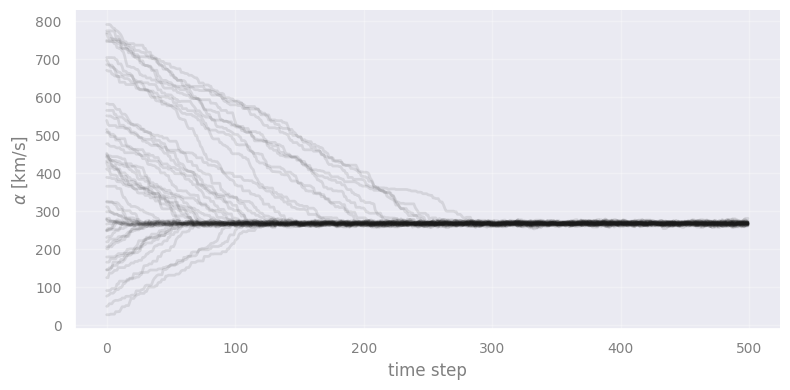

In [27]:
plt.figure()
for param_i in range(n_dim):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel("a" if param_i == 0 else "b")
    for j in range(n_walkers):
        chain = sampler.chain[j, :, param_i]
        plt.plot(chain, "k-", alpha=0.1)
plt.xlabel(r'time step')
plt.ylabel(r'$\alpha$ [km/s]')
plt.tight_layout()
plt.show()

## 3.4 Removing the burn-in phase

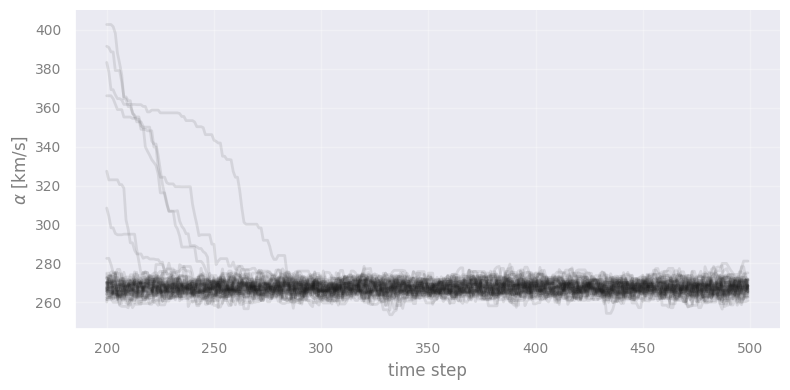

In [28]:
n_burnin = 200
steps = np.array(range(0,n_steps-n_burnin)) + n_burnin

plt.figure()
for param_i in range(n_dim):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel("a" if param_i == 0 else "b")
    for j in range(n_walkers):
        chain = sampler.chain[j, n_burnin:, param_i]
        plt.plot(steps, chain, "k-", alpha=0.1)
plt.xlabel(r'time step')
plt.ylabel(r'$\alpha$ [km/s]')
plt.tight_layout()
plt.show()

## 3.5 Corner plot of all the samples from the converged chains

Converged chain shape      : (50, 300, 1)
Converged flat chain shape : (15000, 1)


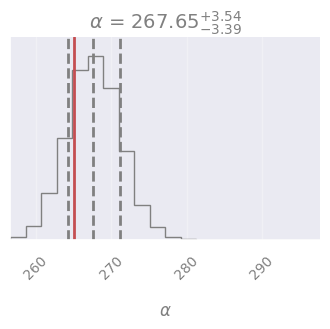

In [15]:
converged_chain = sampler.chain[:, n_burnin:, :]
print("Converged chain shape      :", converged_chain.shape)

flat_converged_chain = converged_chain.reshape(converged_chain.shape[0] * converged_chain.shape[1], -1)
print("Converged flat chain shape :", flat_converged_chain.shape)

fig = corner.corner(flat_converged_chain,
                    quantiles=[0.16, 0.5, 0.84],
                    truths=[a],
                    truth_color="r",
                    labels=[r"$\alpha$", r"$b$"],
                    show_titles=True
                   )

# 4. The stretch move of `emcee`

When we have multiple walkers, we can exploit their distribution in the parameter space to optimize the scale of our exploration. A move from a walker at position $X_k$ can be at the direction of another walker $X_j$, with a step equal to the distance between the walkers times a factor that is randomly sampled in the range $(1/Z, Z)$, where $Z$ is the *stretch factor* (set to $2.0$ in `emcee` by default). Thus, walker $X_k$ can move towards or away from walker $X_j$. The theory behind this move and its compatibility with the Metropolis-Hastings algorithm can be found in <a href="https://msp.org/camcos/2010/5-1/p04.xhtml">Goodman & Weare (2010)</a>.

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/MCMC/images/stretch_move.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=600><center><br>
Figure 3. The stretch move. The light dots represent the non-participating walkers, while the proposal for the next $X_k$ ($Y$)is generated by stretching along the straight line connecting $X_j$ to $X_k$. Original figure from <a href="https://msp.org/camcos/2010/5-1/p04.xhtml">Goodman & Weare (2010)</a>.
<br></center></td></tr></table>

In [36]:
emcee.moves.GaussianMove?

100%|██████████| 500/500 [00:08<00:00, 62.27it/s]


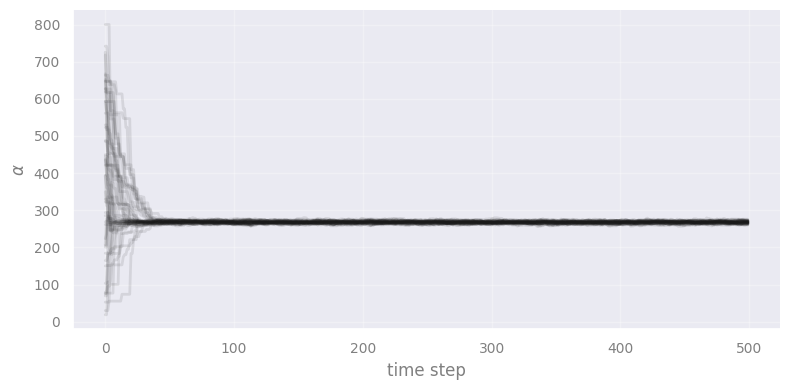

In [39]:
n_walkers = 50
n_dim = 1
n_steps = 500

a_min = 0.0
a_max = 800.0

# set the parameter's initial positions
a_initial = np.random.uniform(a_min, a_max, size=n_walkers)

# take the initial values for each parameter and put them in columns of a 2D array
p0 = np.array([a_initial]).T

sampler = emcee.EnsembleSampler(nwalkers=n_walkers, ndim=n_dim,
                                log_prob_fn=ln_posterior, args=[sample_1],
#                                 moves=emcee.moves.GaussianMove(30.0),
                                )
result = sampler.run_mcmc(p0, nsteps=n_steps, progress=True)

plt.figure()
for param_i in range(n_dim):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel(r"$\alpha$" if param_i == 0 else r"$\beta$")
    for j in range(n_walkers):
        chain = sampler.chain[j, :, param_i]
        plt.plot(chain, "k-", alpha=0.1)

plt.xlabel(r'time step')
#plt.ylabel(r'$\alpha$ [km/s]')
plt.tight_layout()
plt.show()

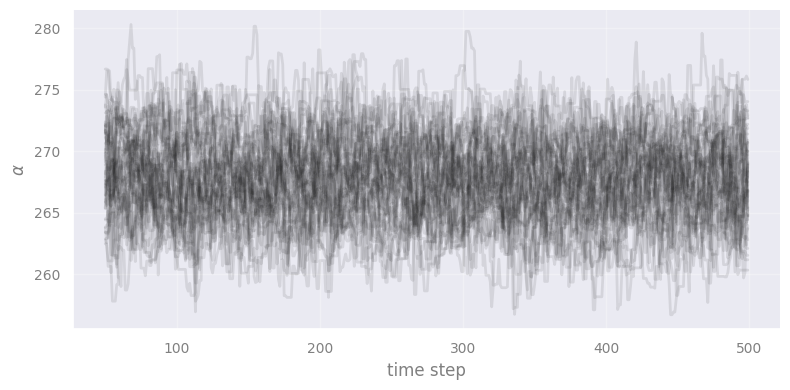

Converged chain shape     : (50, 450, 1)
Converged flatchain shape : (22500, 1)


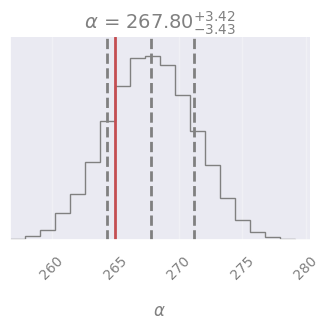

In [40]:
n_burnin = 50
steps = np.array(range(0,n_steps-n_burnin)) + n_burnin

labels = [r"$\alpha$"]
plt.figure()
for param_i in range(n_dim):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel(labels[param_i])
    for j in range(n_walkers):
        chain = sampler.chain[j, n_burnin:, param_i]
        plt.plot(steps, chain, "k-", alpha=0.1)

plt.xlabel(r'time step')
plt.tight_layout()
plt.show()

converged_chain = sampler.chain[:, n_burnin:, :]
print("Converged chain shape     :", converged_chain.shape)

flat_converged_chain = converged_chain.reshape(converged_chain.shape[0] * converged_chain.shape[1], -1)
print("Converged flatchain shape :", flat_converged_chain.shape)

fig = corner.corner(flat_converged_chain,
                    quantiles=[0.16, 0.5, 0.84],
                    truths=[a],
                    truth_color="r",
                    labels=[r"$\alpha$"],
                    show_titles=True
                   )

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 3: starting from the same position</b></font>

Run the MCMC analysis with a very narrow range of initial positions.

</div>

In [42]:
emcee.moves?

100%|██████████| 500/500 [00:05<00:00, 91.09it/s] 


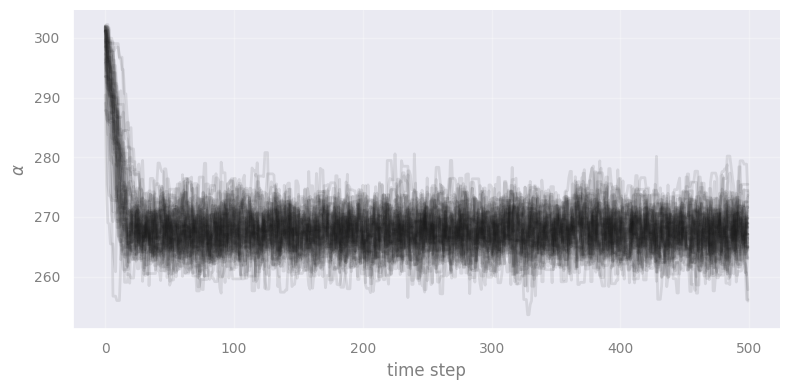

In [44]:
n_walkers = 50
n_dim = 1
n_steps = 500

a_min = 301
a_max = 302

# set the parameter's initial positions
a_initial = np.random.uniform(a_min, a_max, size=n_walkers)

# take the initial values for each parameter and put them in columns of a 2D array
p0 = np.array([a_initial]).T

sampler = emcee.EnsembleSampler(nwalkers=n_walkers, ndim=n_dim,
                                log_prob_fn=ln_posterior, args=[sample_1],
                                 moves=emcee.moves.GaussianMove(30.0),
                                )
result = sampler.run_mcmc(p0, nsteps=n_steps, progress=True)

plt.figure()
for param_i in range(n_dim):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel(r"$\alpha$" if param_i == 0 else r"$\beta$")
    for j in range(n_walkers):
        chain = sampler.chain[j, :, param_i]
        plt.plot(chain, "k-", alpha=0.1)

plt.xlabel(r'time step')
plt.tight_layout()
plt.show()

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

<pre>
a_min = 301
a_max = 302
</pre>
  
</details>
</div>

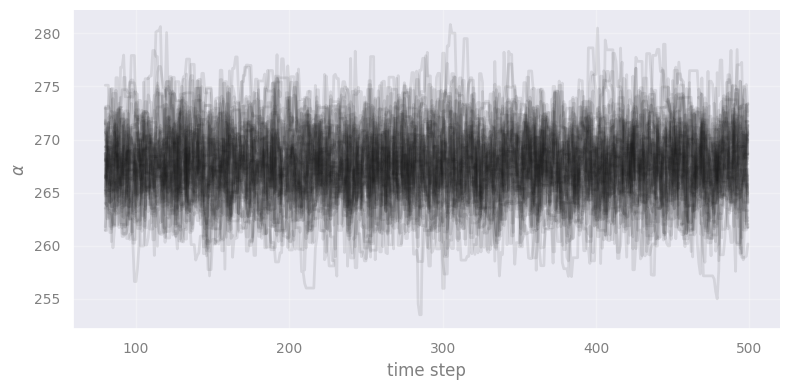

Converged chain shape     : (50, 420, 1)
Converged flatchain shape : (21000, 1)


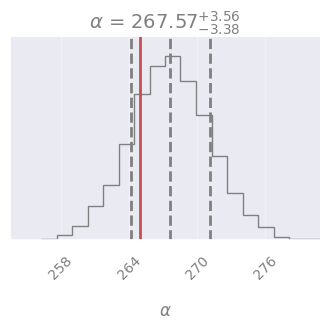

In [19]:
n_burnin = 80
steps = np.array(range(0,n_steps-n_burnin)) + n_burnin

labels = [r"$\alpha$"]
plt.figure()
for param_i in range(n_dim):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel(labels[param_i])
    for j in range(n_walkers):
        chain = sampler.chain[j, n_burnin:, param_i]
        plt.plot(steps, chain, "k-", alpha=0.1)

plt.xlabel(r'time step')
plt.tight_layout()
plt.show()

converged_chain = sampler.chain[:, n_burnin:, :]
print("Converged chain shape     :", converged_chain.shape)

flat_converged_chain = converged_chain.reshape(converged_chain.shape[0] * converged_chain.shape[1], -1)
print("Converged flatchain shape :", flat_converged_chain.shape)

fig = corner.corner(flat_converged_chain,
                    quantiles=[0.16, 0.5, 0.84],
                    truths=[a],
                    truth_color="r",
                    labels=[r"$\alpha$"],
                    show_titles=True
                   )

**bold text**<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: compare all the chains and the time needed by the Gaussian and Stretch steps. What are the advantages of using the *stretch* step?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

1. Using the stretch move takes a little bit longer, but the convergence is so fast that we can save time by reducing the number of steps. For example, 10 walkers taking 1000 steps is equivalent to 100 walkers taking 100 steps. But with the stretch move, having multiple walkers results in faster convergence.
    
2. Even if we start from effectively the same position, the stretch move is able to move and expand the search.

3. Most importantly, with the stretch move we do not need to find the optimal step size!

</details>
</div>

# 5. For advanced users...

In the case of non-linear models, and in many dimensions, MCMC is harder to converge. The number of walkers and steps might need to be adapted.

### Increase the **number of walkers**...

...to explore the parameter space faster in the beginning!

### Increase the **number of steps**...

...to get a better chance for convergence. Fortunately, with `emcee` it is possible to run more steps at will! For example, for the fitting in <a href="https://ui.adsabs.harvard.edu/abs/2020MNRAS.494.5967K/abstract" target="_blank">Kouroumpatzakis et al. (2020)</a> the user was asked if they want to continue or stop after a given number of steps (or detect convergence automatically).

# 5.1 Let's try a more difficult model...

The kick velocities received by NSs are a valid reason to change the orbit of a binary system (e.g. by inducing eccentricity), or disrupt it completely. Studies have shown that NSs in many binaries have not received significant kicks. This supports the *Electron-Capture Supernova* (ECSN) mechanism that makes SuperNova explosions symmetric. Hence, we expect low kick velocities (e.g, [Dessart et al. 2006](https://ui.adsabs.harvard.edu/abs/2006ApJ...644.1063D/abstract)).

The existence of a population of NSs that originated from an ECSN would have the effect of an additional Maxwellian component with lower velocities. Let's investigate further...

We will need **three parameters** to describe the kick velocity distribution of such a mixed population:

* The scale of the core-collapse supernova (CCSN) kick velocity distribution, $\alpha_1$,
* The scale of the more symmetric ECSN kick velocity distribution, $\alpha_2$,
* The fraction of NSs that originated from ECSN, $f$ (a parameter adjusting the relative contribution of the two components).

In [ ]:
a1_true = 20.0
a2_true = 265.0
f_true = 0.4
N = 500
sample_2 = make_velocity_sample(a1_true, a2_true, f_true, N)

v_step = 20.0
v_bins = np.arange(0.0, max(sample_2)+v_step, v_step)
v_plot = np.linspace(0.0, max(sample_2), 1000)
normalization = 1 # N * v_step
plt.figure()
plt.hist(sample_2, bins=v_bins, color="0.9", ec="0.5", label="Data", density=True)
plt.plot(v_plot, normalization * f_true * st.maxwell(scale=a1_true).pdf(v_plot), "g-", label="ECSN distribution")
plt.plot(v_plot, normalization * (1.0 - f_true) * st.maxwell(scale=a2_true).pdf(v_plot), "r-", label="CCSN distribution")
plt.xlabel("Velocity [km/s]")
plt.ylabel("Probability density")
plt.legend(loc="upper right")
plt.show()

In [ ]:
def ln_prior_a1(a1):
    return -np.inf if a1 <= 0 else 0.0

def ln_prior_a2(a2):
    return -np.inf if a2 <= 0 else 0.0

def ln_prior_f(f):
    return -np.inf if f < 0 or f > 1 else 0.0

def ln_prior(a1, a2, f):
    return ln_prior_a1(a1) + ln_prior_a2(a2) + ln_prior_f(f)

def datum_ln_likelihood(v, a1, a2, f):
    return np.log(f * st.maxwell.pdf(v, scale=a1) + (1.0 - f) * st.maxwell.pdf(v, scale=a2))

def ln_likelihood(velocities, a1, a2, f):
    return np.sum(datum_ln_likelihood(velocities, a1, a2, f))

def ln_posterior(parameters, velocities):
    a1, a2, f = parameters
    result = ln_prior(a1, a2, f) + ln_likelihood(velocities, a1, a2, f)
    return -np.inf if np.isnan(result) else result

In [ ]:
n_walkers = 100
n_dim = 3
n_steps = 400

# set the parameter
a1_positions = np.random.uniform(0.0, 400.0, size=n_walkers) #Draw samples from a uniform distribution.
a2_positions = np.random.uniform(0.0, 400.0, size=n_walkers)
f_positions = np.random.uniform(0.0, 1.0, size=n_walkers)

# take the initial values for each parameter and put them in columns of a 2D array
positions = np.array([a1_positions, a2_positions, f_positions]).T

sampler = emcee.EnsembleSampler(nwalkers=n_walkers, ndim=n_dim, log_prob_fn=ln_posterior, args=[sample_2])

In [ ]:
result = sampler.run_mcmc(positions, nsteps=n_steps, progress=True)

In [ ]:
plt.figure()

labels = [r"$\alpha_1$", r"$\alpha_2$", r"$f$"]

for param_i, label_i in zip(range(n_dim), labels):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel(label_i)
    for j in range(n_walkers):
        chain = sampler.chain[j, :, param_i]
        plt.plot(chain, "k-", alpha=0.1)

plt.xlabel(r'time step')
plt.tight_layout()
plt.show()

In [ ]:
n_burnin = 100
steps = np.array(range(0,n_steps-n_burnin)) + n_burnin

for param_i, label_i in zip(range(n_dim), labels):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel(label_i)
    for j in range(n_walkers):
        chain = sampler.chain[j, n_burnin:, param_i]
        plt.plot(steps, chain, "k-", alpha=0.1)

plt.xlabel(r'time step')
plt.tight_layout()
plt.show()

In [ ]:
converged_chain = sampler.chain[:, n_burnin:, :]
print("Converged chain shape     :", converged_chain.shape)

flat_converged_chain = converged_chain.reshape(converged_chain.shape[0] * converged_chain.shape[1], -1)
print("Converged flatchain shape :", flat_converged_chain.shape)

fig = corner.corner(flat_converged_chain,
                    quantiles=[0.16, 0.5, 0.84],
                    truths=[a1_true, a2_true, f_true],
                    truth_color="r",
                    labels=[r"$\alpha_1$", r"$\alpha_2$", r"$f$"],
                    show_titles=True,
#                     range=[0.95]*3,
                   )

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: what is the problem with this solution? Can we do something about it?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

There is a degeneracy in the parameters: $a_1$ and $a_2$ can be exchanged, and the fraction $f$ can be for either of the two populations! The peaks we detect are not representative of the final distributions!

This leads to an unwanted solution, and the walkers spending too much time moving back and forth.

We can break the symmetry by requirying that $a_1 < a_2$. This will happen in the prior!

</details>
</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 4: enforce a single solution</b></font>

</div>

In [ ]:
def ln_prior_a1(a1):
    return -np.inf if a1 <= 0 else 0.0

def ln_prior_a2(a2):
    return -np.inf if a2 <= 0 else 0.0

def ln_prior_f(f):
    return -np.inf if f < 0 or f > 1 else 0.0

def ln_prior(a1, a2, f):
    ...

def datum_ln_likelihood(v, a1, a2, f):
    return np.log(f * st.maxwell.pdf(v, scale=a1) + (1.0 - f) * st.maxwell.pdf(v, scale=a2))

def ln_likelihood(velocities, a1, a2, f):
    return np.sum(datum_ln_likelihood(velocities, a1, a2, f))

def ln_posterior(parameters, velocities):
    a1, a2, f = parameters
    result = ln_prior(a1, a2, f) + ln_likelihood(velocities, a1, a2, f)
    return -np.inf if np.isnan(result) else result

n_walkers = 100
n_dim = 3
n_steps = 400

# set the parameter
a1_positions = np.random.uniform(100.0, 400.0, size=n_walkers)
a2_positions = np.random.uniform(100.0, 400.0, size=n_walkers)
f_positions = np.random.uniform(0.0, 1.0, size=n_walkers)

# take the initial values for each parameter and put them in columns of a 2D array
positions = np.array([a1_positions, a2_positions, f_positions]).T

sampler = emcee.EnsembleSampler(nwalkers=n_walkers, ndim=n_dim, log_prob_fn=ln_posterior, args=[sample_2])

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

<pre>
def ln_prior(a1, a2, f):
    if a1 > a2:
        return -np.inf
    return ln_prior_a1(a1) + ln_prior_a2(a2) + ln_prior_f(f)
</pre>
  
</details>
</div>

In [ ]:
result = sampler.run_mcmc(positions, nsteps=n_steps, progress=True)

In [ ]:
plt.figure()

labels = [r"$\alpha_1$", r"$\alpha_2$", r"$f$"]

for param_i, label_i in zip(range(n_dim), labels):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel(label_i)
    for j in range(n_walkers):
        chain = sampler.chain[j, :, param_i]
        plt.plot(chain, "k-", alpha=0.1)

plt.xlabel(r'time step')
plt.tight_layout()
plt.show()

In [ ]:
n_burnin = 90
steps = np.array(range(0,n_steps-n_burnin)) + n_burnin

for param_i, label_i in zip(range(n_dim), labels):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel(label_i)
    for j in range(n_walkers):
        chain = sampler.chain[j, n_burnin:, param_i]
        plt.plot(steps, chain, "k-", alpha=0.1)

plt.xlabel(r'time step')
plt.tight_layout()
plt.show()

In [ ]:
converged_chain = sampler.chain[:, n_burnin:, :]
print("Converged chain shape     :", converged_chain.shape)

flat_converged_chain = converged_chain.reshape(converged_chain.shape[0] * converged_chain.shape[1], -1)
print("Converged flatchain shape :", flat_converged_chain.shape)

fig = corner.corner(flat_converged_chain,
                    quantiles=[0.16, 0.5, 0.84],
                    truths=[a1_true, a2_true, f_true],
                    truth_color="r",
                    labels=[r"$\alpha_1$", r"$\alpha_2$", r"$f$"],
                    show_titles=True,
#                     range=[0.95]*3,
                   )

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 5: another dataset with $a_1 = a_2$</b></font>
    
* You can somehow see a slight preference of using only one component (the peaks at 0 and 1 in the $f$ distribution).
* Also, when the $f$ is 0 or 1, you see that $a_1$ and $a_2$ are better constrained respectively (you don't care of the parameter of a component that doesn't participate at all in the likelihood).
* when f is not extreme, a1 and a2 take more or less the same value... to create an up-scaled version of the original distribution!

</div>

In [ ]:
a1_true = 265.0
a2_true = 265.0
f_true = 0.4
N = 500
sample_3 = make_velocity_sample(a1_true, a2_true, f_true, N)

v_step = 20.0
v_bins = np.arange(0.0, max(sample_3)+v_step, v_step)
v_plot = np.linspace(0.0, max(sample_3), 1000)
normalization = 1 # N * v_step
plt.figure()
plt.hist(sample_3, bins=v_bins, color="0.9", ec="0.5", label="Data", density=True)
plt.plot(v_plot, normalization * f_true * st.maxwell(scale=a1_true).pdf(v_plot), "g-", label="ECSN distribution")
plt.plot(v_plot, normalization * (1.0 - f_true) * st.maxwell(scale=a2_true).pdf(v_plot), "r-", label="CCSN distribution")
plt.xlabel("Velocity (km/s)")
plt.ylabel("Number of NSs")
plt.legend(loc="upper right")
plt.show()

In [ ]:
def ln_prior_a1(a1):
    return -np.inf if a1 <= 0 else 0.0

def ln_prior_a2(a2):
    return -np.inf if a2 <= 0 else 0.0

def ln_prior_f(f):
    return -np.inf if f < 0 or f > 1 else 0.0

def ln_prior(a1, a2, f):
    if a1 > a2:
        return -np.inf
    return ln_prior_a1(a1) + ln_prior_a2(a2) + ln_prior_f(f)

def datum_ln_likelihood(v, a1, a2, f):
    return np.log(f * st.maxwell.pdf(v, scale=a1) + (1.0 - f) * st.maxwell.pdf(v, scale=a2))

def ln_likelihood(velocities, a1, a2, f):
    return np.sum(datum_ln_likelihood(velocities, a1, a2, f))

def ln_posterior(parameters, velocities):
    a1, a2, f = parameters
    result = ln_prior(a1, a2, f) + ln_likelihood(velocities, a1, a2, f)
    return -np.inf if np.isnan(result) else result


n_walkers = 100
n_dim = 3
n_steps = 400

# set the parameter
a1_positions = np.random.uniform(100.0, 400.0, size=n_walkers)
a2_positions = np.random.uniform(100.0, 400.0, size=n_walkers)
f_positions = np.random.uniform(0.0, 1.0, size=n_walkers)

# take the initial values for each parameter and put them in columns of a 2D array
positions = np.array([a1_positions, a2_positions, f_positions]).T


sampler = emcee.EnsembleSampler(nwalkers=n_walkers, ndim=n_dim, log_prob_fn=ln_posterior, args=[sample_3])
result = sampler.run_mcmc(positions, nsteps=n_steps, progress=True)

In [ ]:
plt.figure()

labels = [r"$\alpha_1$", r"$\alpha_2$", r"$f$"]

for param_i, label_i in zip(range(n_dim), labels):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel(label_i)
    for j in range(n_walkers):
        chain = sampler.chain[j, :, param_i]
        plt.plot(chain, "k-", alpha=0.1)

plt.xlabel(r'time step')
plt.tight_layout()
plt.show()

In [ ]:
n_burnin = 50
steps = np.array(range(0,n_steps-n_burnin)) + n_burnin

for param_i, label_i in zip(range(n_dim), labels):
    plt.subplot(n_dim, 1, 1+param_i)
    plt.ylabel(label_i)
    for j in range(n_walkers):
        chain = sampler.chain[j, n_burnin:, param_i]
        plt.plot(steps, chain, "k-", alpha=0.1)

plt.xlabel(r'time step')
plt.tight_layout()
plt.show()

In [ ]:
converged_chain = sampler.chain[:, n_burnin:, :]
print("Converged chain shape     :", converged_chain.shape)

flat_converged_chain = converged_chain.reshape(converged_chain.shape[0] * converged_chain.shape[1], -1)
print("Converged flatchain shape :", flat_converged_chain.shape)

fig = corner.corner(flat_converged_chain,
                    quantiles=[0.16, 0.5, 0.84],
                    truths=[a1_true, a2_true, f_true],
                    truth_color="r",
                    labels=[r"$\alpha_1$", r"$\alpha_2$", r"$f$"],
                    show_titles=True,
                    range=[0.95]*3,
                   )

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: Explain the structures in the corner plot</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

When $a_1 = a_2$ the fraction parameter is unconstrained because it lacks meaning! However, then the fraction is 0 or 1, then the contribution of one component is minimal, and therefore, its scale is unconstrained. On the other hand, for intermediate values, the two scales converge to the correct value. The "angle" in the $a_1$-$a_2$ plot is created by the inequality enforced by the prior.

</details>
</div>

In [ ]:
# EOF